In [1]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [2]:
import pandas as pd

In [4]:
import io
df = pd.read_csv(io.BytesIO(uploaded['Online Retail.xlsx'])))

SyntaxError: unmatched ')' (1541150685.py, line 2)

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.csv to Online Retail.csv


In [6]:
import pandas as pd

In [8]:
import io
df = pd.read_csv(io.BytesIO(uploaded['Online Retail.csv']))

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
import io
df = pd.read_csv(io.BytesIO(uploaded['Online Retail.csv']))
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom


In [14]:
print("Dataset shape:", df.shape)

Dataset shape: (541909, 8)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [16]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [18]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [19]:
df = df.dropna(subset=['CustomerID'])

In [20]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [21]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [22]:
df = df.drop_duplicates()

In [23]:
df = df.drop_duplicates()

In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [26]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [27]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [29]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [30]:
print("Cleaned dataset shape:", df.shape)
print("Missing values:")
print(df.isnull().sum())

Cleaned dataset shape: (392692, 9)
Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64


In [31]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


In [32]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [33]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [34]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [35]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [36]:
print("Average Recency:", rfm['Recency'].mean())
print("Average Frequency:", rfm['Frequency'].mean())
print("Average Monetary:", rfm['Monetary'].mean())

Average Recency: 92.53642231443061
Average Frequency: 4.272014753342554
Average Monetary: 2048.688080682342


In [37]:
print("Total customers:", rfm.shape[0])

Total customers: 4338


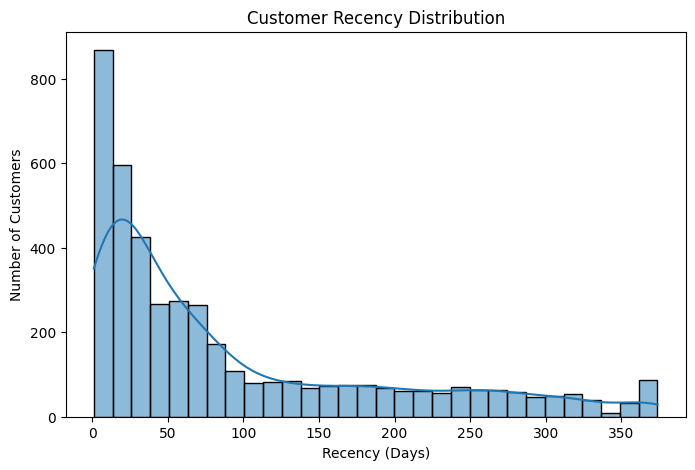

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(rfm['Recency'], bins=30, kde=True)

plt.title('Customer Recency Distribution')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')

plt.show()

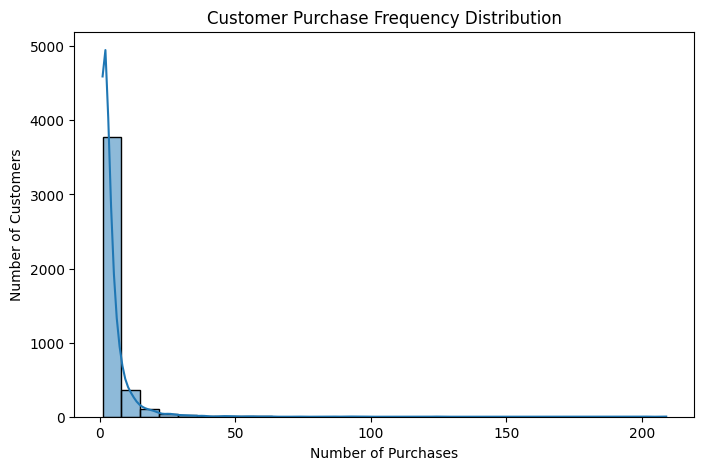

In [39]:
plt.figure(figsize=(8, 5))

sns.histplot(rfm['Frequency'], bins=30, kde=True)

plt.title('Customer Purchase Frequency Distribution')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')

plt.show()

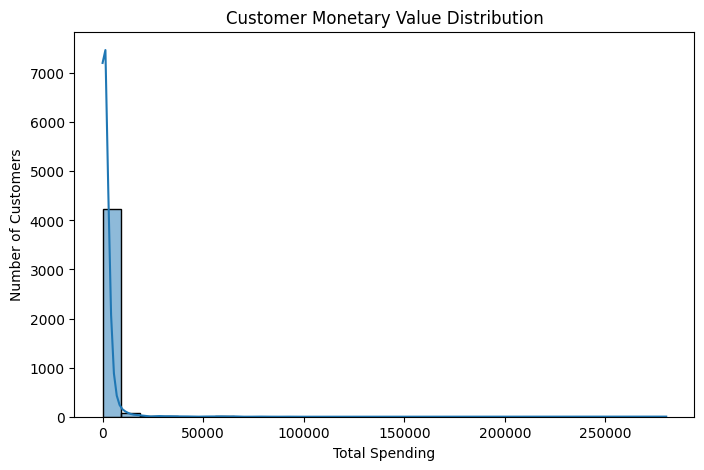

In [40]:
plt.figure(figsize=(8, 5))

sns.histplot(rfm['Monetary'], bins=30, kde=True)

plt.title('Customer Monetary Value Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')

plt.show()

In [41]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [42]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    index=rfm.index,
    columns=['Recency', 'Frequency', 'Monetary']
)

In [43]:
rfm_scaled.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [44]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,2.293130e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.276151e-01
25%,-7.453445e-01,-4.250965e-01,-1.939190e-01
50%,-4.153533e-01,-2.951776e-01,-1.536162e-01
75%,4.946227e-01,9.457903e-02,-4.319704e-02
max,2.814561e+00,2.659803e+01,3.096074e+01


In [45]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

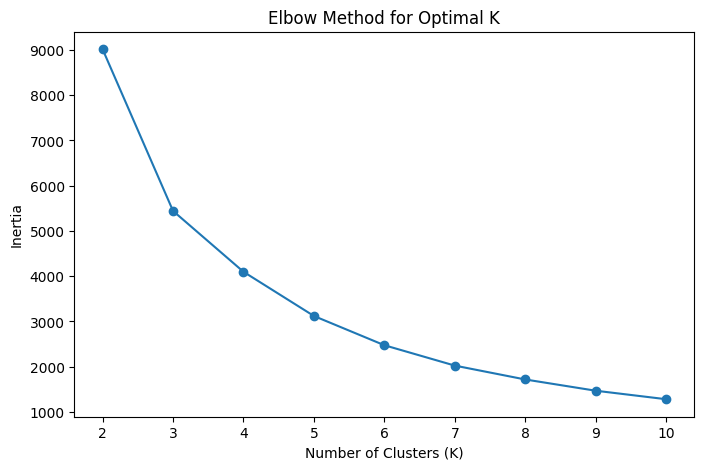

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(K, inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

In [47]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [48]:
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [49]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [50]:
rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,3054
1,1067
2,13
3,204


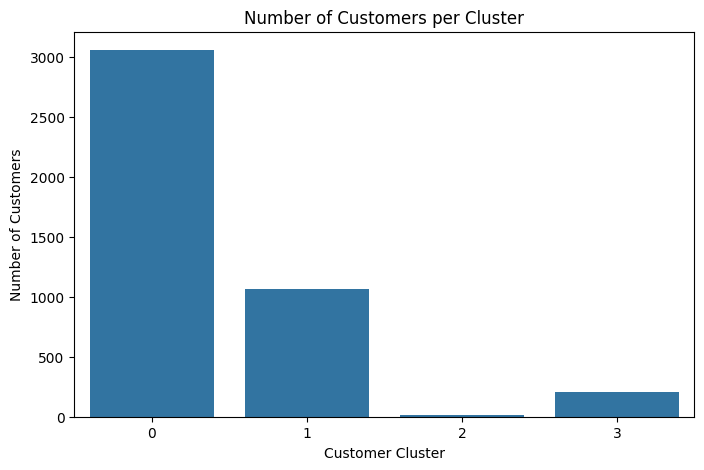

In [52]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x='Cluster'
)

plt.title('Number of Customers per Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')

plt.show()

In [53]:
cluster_profile = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [54]:
cluster_names = {
    0: 'Regular Customers',
    1: 'At-Risk Customers',
    2: 'VIP Customers',
    3: 'Loyal High-Value Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal High-Value Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,At-Risk Customers


In [55]:
rfm['Segment'].value_counts()

,count
Segment,
Regular Customers,3054
At-Risk Customers,1067
Loyal High-Value Customers,204
VIP Customers,13


In [56]:
segment_profile = rfm.groupby('Segment')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean().round(2)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
At-Risk Customers,248.08,1.55,478.85
Loyal High-Value Customers,15.50,22.33,12690.50
Regular Customers,43.70,3.68,1353.63
VIP Customers,7.38,82.54,127187.96


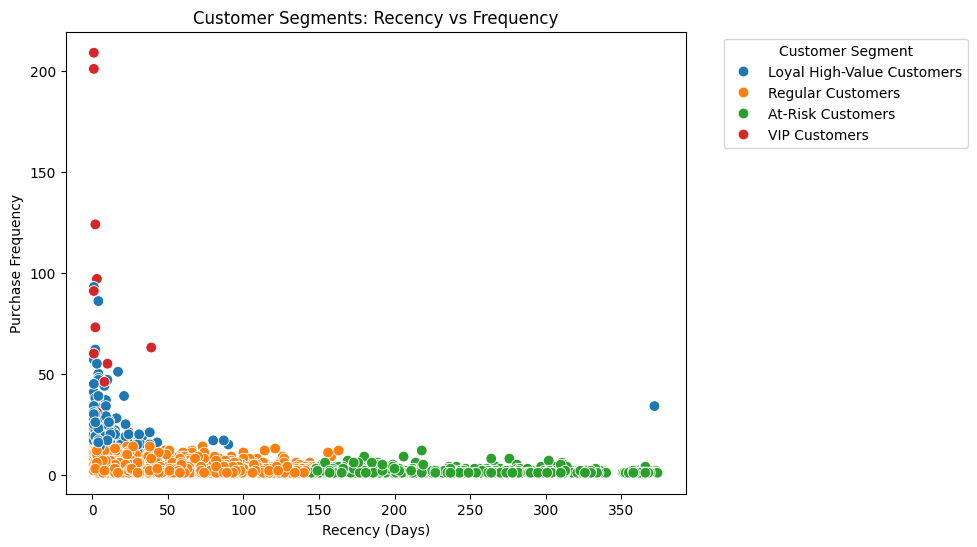

In [57]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Segment',
    s=60
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Purchase Frequency')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

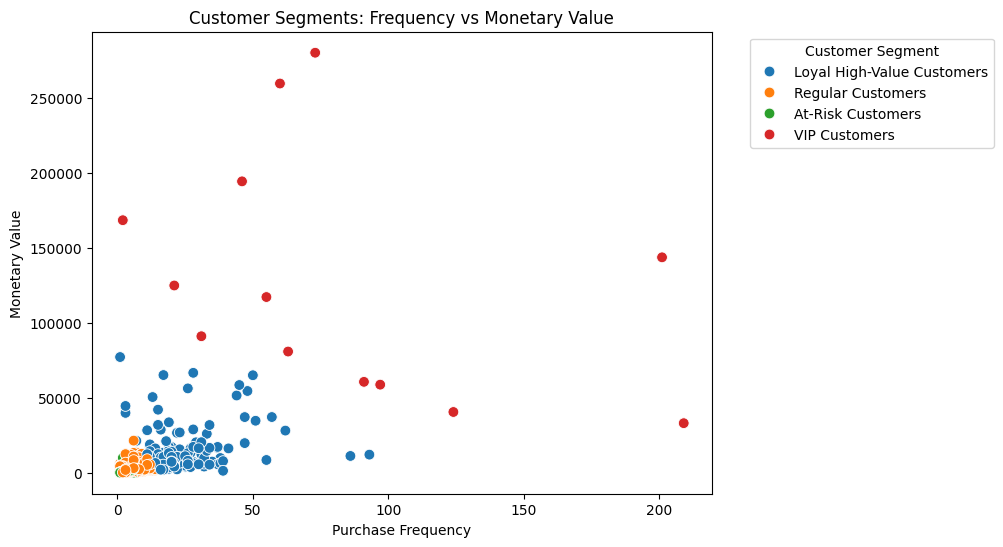

In [58]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    s=60
)

plt.title('Customer Segments: Frequency vs Monetary Value')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

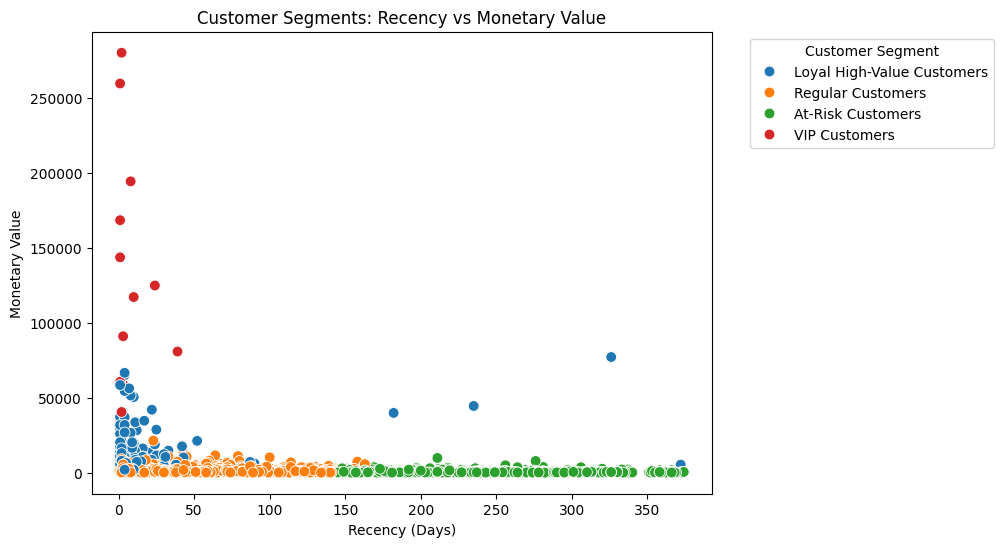

In [59]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    s=60
)

plt.title('Customer Segments: Recency vs Monetary Value')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

## Conclusion

RFM analysis and K-Means clustering were used to segment customers according to their purchasing behaviour. Four distinct customer segments were identified: Regular Customers, At-Risk Customers, VIP Customers, and Loyal High-Value Customers.

VIP Customers represent the most valuable group because they purchase frequently, purchased recently, and have very high monetary value. At-Risk Customers show the lowest engagement and should be targeted through customer reactivation campaigns.

The segmentation can help the business move away from a one-size-fits-all marketing strategy and instead create targeted campaigns for different customer groups.

### Key Business Recommendations

1. Reward VIP and Loyal High-Value Customers with exclusive loyalty benefits and personalized offers.
2. Launch targeted win-back campaigns for At-Risk Customers to encourage repeat purchases.
3. Use personalized recommendations and cross-selling strategies to increase the spending and frequency of Regular Customers.
4. Monitor customer segments periodically to identify customers moving from valuable segments into the At-Risk segment.